In [1]:
#importing the libraries needed for th project
import pandas as pd
import numpy as np
import matplotlib.pyplot as mat

mat.style.use("ggplot")

In [2]:
#reading the data in jupyter notebook
data = pd.read_csv("../data_folder/ecommerce_sales_dataset.csv")

In [3]:
data.head(3)

,Order_ID,Order_Date,Year,Month,Quarter,Season,Customer_ID,Customer_Gender,Customer_Segment,Region,...,Discount,Revenue,Cost,Profit,Profit_Margin_%,Shipping_Cost,Shipping_Method,Shipping_Days,Payment_Method,Order_Status
0,ORD-000001,2023-01-18,2023,1,Q1,Winter,CUST-02791,Male,New,North America,...,0.00,3642.80,2444.11,1198.69,32.91,2.25,Economy,4,Google Pay,Delivered
1,ORD-000002,2023-11-13,2023,11,Q4,Fall,CUST-02763,Female,Regular,North America,...,0.25,33.88,28.32,5.56,16.41,4.72,Economy,5,Credit Card,Delivered
2,ORD-000003,2022-04-28,2022,4,Q2,Spring,CUST-05729,Male,Regular,North America,...,0.00,241.30,161.41,79.89,33.11,13.28,Standard,8,Credit Card,Processing


## Cleaning our data

1) Removing all columns that do not contribute to the overall profitability
2) checking for missing values
3) removing impossible values if there is
4) converting strings to numbers if needed

In [4]:
# knowing our date datatype
data.Order_Date.dtype

dtype('O')

In [5]:
# parsing the date data type to machine readable date-time object

data = pd.read_csv("../data_folder/ecommerce_sales_dataset.csv", low_memory=False, parse_dates=["Order_Date"])

In [6]:
data.Order_Date.dtype

dtype('<M8[ns]')

In [7]:

# viewing the first 10 date-time object

data["Order_Date"][:10]

0   2023-01-18
1   2023-11-13
2   2022-04-28
3   2021-10-22
4   2023-08-06
5   2021-06-25
6   2024-02-07
7   2022-06-05
8   2022-11-05
9   2023-03-14
Name: Order_Date, dtype: datetime64[ns]

In [10]:
# dropping the columns order id, customer id because they are already uner date

cleaned_data = data.drop(columns=["Order_ID"])

In [11]:
cleaned_data.head(3)

,Order_Date,Year,Month,Quarter,Season,Customer_ID,Customer_Gender,Customer_Segment,Region,Country,...,Discount,Revenue,Cost,Profit,Profit_Margin_%,Shipping_Cost,Shipping_Method,Shipping_Days,Payment_Method,Order_Status
0,2023-01-18,2023,1,Q1,Winter,CUST-02791,Male,New,North America,Mexico,...,0.00,3642.80,2444.11,1198.69,32.91,2.25,Economy,4,Google Pay,Delivered
1,2023-11-13,2023,11,Q4,Fall,CUST-02763,Female,Regular,North America,USA,...,0.25,33.88,28.32,5.56,16.41,4.72,Economy,5,Credit Card,Delivered
2,2022-04-28,2022,4,Q2,Spring,CUST-05729,Male,Regular,North America,Canada,...,0.00,241.30,161.41,79.89,33.11,13.28,Standard,8,Credit Card,Processing


In [12]:
# checking for the number of unique products to determine if trainable
cleaned_data["Product_Name"].value_counts()

Product_Name
Moisturizing Cream      225
Adobe Creative Cloud    224
Vitamin C Serum         223
Antivirus Pro           221
Rich Dad Poor Dad       213
                       ... 
ASUS ZenBook             92
Xiaomi 13                91
MacBook Air M2           88
Google Pixel 7           87
Bose QC45                75
Name: count, Length: 70, dtype: int64

In [13]:
cleaned_data["Product_Name"].nunique()

70

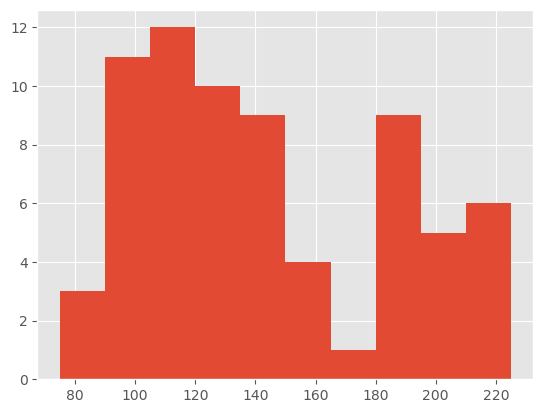

In [14]:
# checking the distribution of the number of product name
cleaned_data["Product_Name"].value_counts().hist();

In [15]:
#checking the new data size and shape to confirm the columns have been removed and our data is still accurate
cleaned_data.shape

(10000, 25)

In [16]:
cleaned_data.size

250000

In [17]:
cleaned_data.head(2)

,Order_Date,Year,Month,Quarter,Season,Customer_ID,Customer_Gender,Customer_Segment,Region,Country,...,Discount,Revenue,Cost,Profit,Profit_Margin_%,Shipping_Cost,Shipping_Method,Shipping_Days,Payment_Method,Order_Status
0,2023-01-18,2023,1,Q1,Winter,CUST-02791,Male,New,North America,Mexico,...,0.00,3642.80,2444.11,1198.69,32.91,2.25,Economy,4,Google Pay,Delivered
1,2023-11-13,2023,11,Q4,Fall,CUST-02763,Female,Regular,North America,USA,...,0.25,33.88,28.32,5.56,16.41,4.72,Economy,5,Credit Card,Delivered


In [18]:
# viewing the new data column names
cleaned_data.info

<bound method DataFrame.info of      Order_Date  Year  Month Quarter  Season Customer_ID Customer_Gender  \
0    2023-01-18  2023      1      Q1  Winter  CUST-02791            Male   
1    2023-11-13  2023     11      Q4    Fall  CUST-02763          Female   
2    2022-04-28  2022      4      Q2  Spring  CUST-05729            Male   
3    2021-10-22  2021     10      Q4    Fall  CUST-06490          Female   
4    2023-08-06  2023      8      Q3  Summer  CUST-07594          Female   
...         ...   ...    ...     ...     ...         ...             ...   
9995 2023-07-15  2023      7      Q3  Summer  CUST-01740          Female   
9996 2022-01-01  2022      1      Q1  Winter  CUST-01137          Female   
9997 2024-04-23  2024      4      Q2  Spring  CUST-01664          Female   
9998 2021-09-22  2021      9      Q3    Fall  CUST-04665            Male   
9999 2023-03-25  2023      3      Q1  Spring  CUST-05360          Female   

     Customer_Segment         Region Country  ... Disco

## Sorting Dataframe by date


In [19]:
cleaned_data.sort_values(by=["Order_Date"], inplace=True, ascending=True)

In [20]:
cleaned_data.head(20)

,Order_Date,Year,Month,Quarter,Season,Customer_ID,Customer_Gender,Customer_Segment,Region,Country,...,Discount,Revenue,Cost,Profit,Profit_Margin_%,Shipping_Cost,Shipping_Method,Shipping_Days,Payment_Method,Order_Status
1451,2021-01-05,2021,1,Q1,Winter,CUST-02274,Female,New,Asia,India,...,0.40,112.19,130.29,-18.10,-16.13,18.27,Standard,22,Cash on Delivery,Delivered
1302,2021-01-15,2021,1,Q1,Winter,CUST-04879,Female,Premium,Middle East,Jordan,...,0.50,931.58,870.47,61.11,6.56,37.13,Express,18,Credit Card,Delivered
8280,2021-01-20,2021,1,Q1,Winter,CUST-07995,Female,Regular,Middle East,Egypt,...,0.10,7528.32,3884.40,3643.92,48.40,8.60,Standard,17,Google Pay,Delivered
7857,2021-01-22,2021,1,Q1,Winter,CUST-03253,Male,VIP,Asia,South Korea,...,0.15,155.46,95.22,60.24,38.75,57.06,Overnight,17,Debit Card,Delivered
4253,2021-01-25,2021,1,Q1,Winter,CUST-03980,Female,Regular,Asia,Japan,...,0.00,246.50,142.91,103.59,42.02,94.03,Overnight,10,Credit Card,Delivered
7635,2021-01-29,2021,1,Q1,Winter,CUST-01375,Female,New,North America,USA,...,0.10,265.79,157.45,108.34,40.76,40.17,Express,8,Bank Transfer,Delivered
2388,2021-01-30,2021,1,Q1,Winter,CUST-05921,Male,Regular,Asia,Singapore,...,0.10,36.59,28.54,8.05,22.00,7.26,Economy,18,Bank Transfer,Delivered
1813,2021-02-01,2021,2,Q1,Winter,CUST-07708,Male,Regular,Middle East,Jordan,...,0.00,671.20,428.77,242.43,36.12,9.18,Economy,8,Apple Pay,Delivered
3866,2021-02-04,2021,2,Q1,Winter,CUST-01205,Female,Regular,Europe,France,...,0.15,3156.36,2566.30,590.06,18.69,8.00,Economy,13,Google Pay,Delivered
8594,2021-02-05,2021,2,Q1,Winter,CUST-04263,Female,New,Middle East,UAE,...,0.25,93.44,91.54,1.90,2.03,17.93,Standard,14,Cash on Delivery,Delivered


In [21]:
# checking whether order status could have effect on profitability

unique_values = {i: cleaned_data[i].nunique() for i in cleaned_data.columns}
unique_values

{'Order_Date': 1355,
 'Year': 4,
 'Month': 12,
 'Quarter': 4,
 'Season': 4,
 'Customer_ID': 5348,
 'Customer_Gender': 2,
 'Customer_Segment': 4,
 'Region': 4,
 'Country': 18,
 'Category': 5,
 'Sub_Category': 14,
 'Product_Name': 70,
 'Unit_Price': 8391,
 'Quantity': 10,
 'Discount': 9,
 'Revenue': 9066,
 'Cost': 8824,
 'Profit': 7973,
 'Profit_Margin_%': 5263,
 'Shipping_Cost': 5276,
 'Shipping_Method': 4,
 'Shipping_Days': 23,
 'Payment_Method': 7,
 'Order_Status': 4}

In [22]:
#checking for duplicated rows

cleaned_data.duplicated().sum()

np.int64(0)

In [23]:
unique_names = {i: cleaned_data[i].unique() for i in cleaned_data.columns}
unique_names

{'Order_Date': <DatetimeArray>
 ['2021-01-05 00:00:00', '2021-01-15 00:00:00', '2021-01-20 00:00:00',
  '2021-01-22 00:00:00', '2021-01-25 00:00:00', '2021-01-29 00:00:00',
  '2021-01-30 00:00:00', '2021-02-01 00:00:00', '2021-02-04 00:00:00',
  '2021-02-05 00:00:00',
  ...
  '2024-12-03 00:00:00', '2024-12-04 00:00:00', '2024-12-07 00:00:00',
  '2024-12-08 00:00:00', '2024-12-09 00:00:00', '2024-12-10 00:00:00',
  '2024-12-11 00:00:00', '2024-12-19 00:00:00', '2024-12-21 00:00:00',
  '2024-12-24 00:00:00']
 Length: 1355, dtype: datetime64[ns],
 'Year': array([2021, 2022, 2023, 2024]),
 'Month': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12]),
 'Quarter': array(['Q1', 'Q2', 'Q3', 'Q4'], dtype=object),
 'Season': array(['Winter', 'Spring', 'Summer', 'Fall'], dtype=object),
 'Customer_ID': array(['CUST-02274', 'CUST-04879', 'CUST-07995', ..., 'CUST-02948',
        'CUST-01452', 'CUST-04118'], shape=(5348,), dtype=object),
 'Customer_Gender': array(['Female', 'Male'], dtype=object

In [24]:
cleaned_data.head(3)

,Order_Date,Year,Month,Quarter,Season,Customer_ID,Customer_Gender,Customer_Segment,Region,Country,...,Discount,Revenue,Cost,Profit,Profit_Margin_%,Shipping_Cost,Shipping_Method,Shipping_Days,Payment_Method,Order_Status
1451,2021-01-05,2021,1,Q1,Winter,CUST-02274,Female,New,Asia,India,...,0.4,112.19,130.29,-18.10,-16.13,18.27,Standard,22,Cash on Delivery,Delivered
1302,2021-01-15,2021,1,Q1,Winter,CUST-04879,Female,Premium,Middle East,Jordan,...,0.5,931.58,870.47,61.11,6.56,37.13,Express,18,Credit Card,Delivered
8280,2021-01-20,2021,1,Q1,Winter,CUST-07995,Female,Regular,Middle East,Egypt,...,0.1,7528.32,3884.40,3643.92,48.40,8.60,Standard,17,Google Pay,Delivered


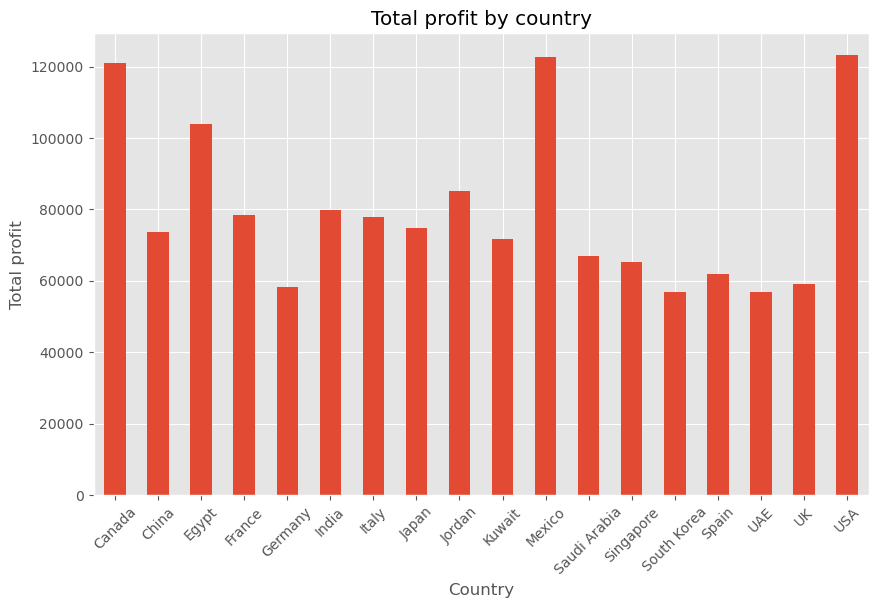

In [25]:
## viewing the relationship between country and profit

country_profit = cleaned_data.groupby("Country")["Profit"].sum()
country_profit.plot(kind = "bar", figsize=(10, 6))

mat.title("Total profit by country")
mat.xlabel("Country")
mat.ylabel("Total profit")
mat.xticks(rotation=45)
mat.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_29972\800824528.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  profit_by_month = cleaned_data.groupby("Month")["Profit"].sum()


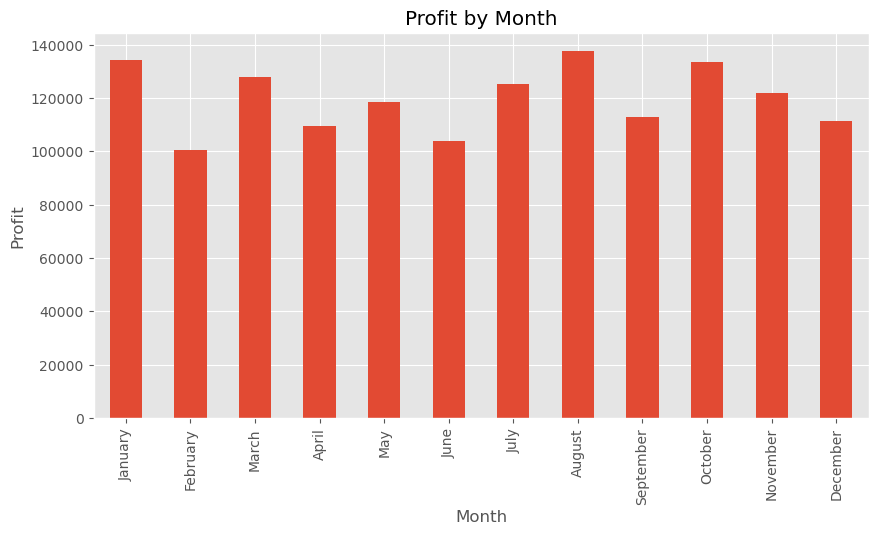

In [26]:
## viewing the relationship between date and profit

month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

cleaned_data["Month"] = pd.Categorical(
    cleaned_data["Order_Date"].dt.month_name(),
    categories=month_order,
    ordered=True
)

profit_by_month = cleaned_data.groupby("Month")["Profit"].sum()

profit_by_month.plot(kind="bar", figsize=(10,5))

mat.title("Profit by Month")
mat.xlabel("Month")
mat.ylabel("Profit")
mat.show()

In [27]:
cleaned_data.head(4)

,Order_Date,Year,Month,Quarter,Season,Customer_ID,Customer_Gender,Customer_Segment,Region,Country,...,Discount,Revenue,Cost,Profit,Profit_Margin_%,Shipping_Cost,Shipping_Method,Shipping_Days,Payment_Method,Order_Status
1451,2021-01-05,2021,January,Q1,Winter,CUST-02274,Female,New,Asia,India,...,0.40,112.19,130.29,-18.10,-16.13,18.27,Standard,22,Cash on Delivery,Delivered
1302,2021-01-15,2021,January,Q1,Winter,CUST-04879,Female,Premium,Middle East,Jordan,...,0.50,931.58,870.47,61.11,6.56,37.13,Express,18,Credit Card,Delivered
8280,2021-01-20,2021,January,Q1,Winter,CUST-07995,Female,Regular,Middle East,Egypt,...,0.10,7528.32,3884.40,3643.92,48.40,8.60,Standard,17,Google Pay,Delivered
7857,2021-01-22,2021,January,Q1,Winter,CUST-03253,Male,VIP,Asia,South Korea,...,0.15,155.46,95.22,60.24,38.75,57.06,Overnight,17,Debit Card,Delivered


In [30]:
cleaned_data.to_csv("../data_folder/cleaned_data.csv", index=False)